# Testing new ART transmission and mortality

The goal is to allow for ART assignment to specify whether someone achieves EffectiveART or NonSuppressiveART, similar to ARTMortalityTable intervention from EMOD-HIV. 

I will implement, test, and demonstrate the following new model features

* New individual property which tracks ART Adherence - Effective vs NonSuppressive ART
* Allow Transmission to vary depending on Effective vs NonSuppressive ART
* Allow HIV-derived mortality to vary depending on Effective vs. NonSuppressive ART, as well as by age and sex

In [1]:
import starsim as ss
import stisim as sti
import matplotlib.pyplot as plt
import sciris as sc
import numpy as np
import pandas as pd

## Testing transmission

### Create a new class for testing mortality in each ART category

In [2]:
class ARTStatusTracker(ss.Analyzer):
    """
    Track deaths, living population, and onward transmissions, each broken
    out by ART-adherence category.

    Deaths need special handling: HIV.step_die() clears art_naive/on_art/
    on_effective_art/on_nonsuppressive_art/art_discontinued for agents who
    die (as it does for all disease states), so an agent's category can't be
    read off the live state after death. Instead, cache each agent's category
    at the end of every timestep, and when an agent dies (`ti_dead == ti`,
    which -- unlike the other states -- IS preserved through step_die), look
    up their most recently cached category rather than the (already-cleared)
    live state.

    Living population and transmission-source counts don't have this problem
    -- both only ever look at currently-alive, currently-infectious agents,
    so the live state is read directly, no caching needed.

    Requires `ss.infection_log()` to also be included in `analyzers=` for the
    transmission-attribution results to be populated (that's what actually
    turns on source/target tracking inside the HIV module).
    """
    CATEGORIES = ['art_naive', 'on_effective_art', 'on_nonsuppressive_art', 'art_discontinued']

    def __init__(self):
        super().__init__()
        self._cache = {}  # uid -> category, as of the end of the previous timestep

    def init_results(self):
        super().init_results()
        results = []
        for cat in self.CATEGORIES + ['on_art']:
            results += [
                ss.Result(f'deaths_{cat}', dtype=int, label=f'Deaths ({cat})'),
                ss.Result(f'n_alive_{cat}', dtype=int, label=f'Living with HIV ({cat})'),
                ss.Result(f'new_infections_from_{cat}', dtype=int, label=f'New infections from {cat}'),
            ]
        self.define_results(*results)

    def step(self):
        hiv = self.sim.diseases.hiv
        ti = self.ti

        # Deaths: attribute using each agent's cached (pre-death) category
        died_uids = (hiv.ti_dead == ti).uids
        for uid in died_uids:
            cat = self._cache.pop(int(uid), None)
            if cat is None:
                continue
            self.results[f'deaths_{cat}'][ti] += 1
            if cat in ('on_effective_art', 'on_nonsuppressive_art'):
                self.results['deaths_on_art'][ti] += 1

        # Onward transmissions this timestep, by source uid (requires ss.infection_log())
        log = hiv.infection_log
        new_source_uids = []
        if log is not None:
            for source, _target, t in log.edges(keys=True):
                if t == hiv.now and not pd.isna(source):
                    new_source_uids.append(int(source))
        src_uids = ss.uids(new_source_uids) if new_source_uids else ss.uids([])

        # Living population and transmission-source counts, by category
        for cat in self.CATEGORIES:
            alive_uids = (hiv.infected & hiv[cat]).uids
            n_alive = len(alive_uids)
            n_from_cat = int(hiv[cat][src_uids].sum()) if len(src_uids) else 0
            self.results[f'n_alive_{cat}'][ti] = n_alive
            self.results[f'new_infections_from_{cat}'][ti] = n_from_cat
            if cat in ('on_effective_art', 'on_nonsuppressive_art'):
                self.results['n_alive_on_art'][ti] += n_alive
                self.results['new_infections_from_on_art'][ti] += n_from_cat

        # Refresh the death-attribution cache for next timestep
        for cat in self.CATEGORIES:
            for uid in hiv[cat].uids:
                self._cache[int(uid)] = cat


def get_by_art_status(sim, metric):
    """
    Extract a result time series stratified by ART status.

    Args:
        sim: a run Sim with an ARTStatusTracker analyzer attached
        metric (str): result prefix -- one of 'deaths', 'n_alive', 'new_infections_from'

    Returns:
        dict mapping category name -> np.array (one value per timestep),
        for each of ARTStatusTracker.CATEGORIES plus the 'on_art' aggregate
    """
    tracker = sim.analyzers.artstatustracker
    groups = ARTStatusTracker.CATEGORIES + ['on_art']
    return {cat: tracker.results[f'{metric}_{cat}'].values for cat in groups}

### Run simulation

In [3]:
# Diagnose people first -- ART only initiates agents who are hiv.diagnosed.
hiv_test = sti.HIVTest(test_prob_data=0.3, start=2000)

# Absolute-count coverage target: ramps from 0 to 1000 people on ART between
# 2004 and 2005, then holds at 1000 for the rest of the sim. 50/50 split
# between effective (virally-suppressive) and non-suppressive ART.
art = sti.ART(
    coverage={'year': [2004, 2005], 'value': [0, 1000], 'format': 'n'},
    p_effective_art=0.5,
)
art_tracker = ARTStatusTracker()

sim = sti.Sim(
    diseases=sti.HIV(init_prev=ss.bernoulli(p=0.2)),
    n_agents=10_000, start=2000, stop=2020,
    interventions=[hiv_test, art],
    analyzers=[ss.infection_log(), art_tracker],
    rand_seed=2
)
sim.run(verbose=0)

Initializing sim with 10000 agents


Sim(n=10000; 2000—2020; networks=structuredsexual, maternalnet; diseases=hiv; interventions=hivtest, art; analyzers=infection_log, artstatustracker)

### Checking simulaiton results

In [4]:
hiv_res = sim.results.hiv
timevec = hiv_res.timevec
groups = ARTStatusTracker.CATEGORIES + ['on_art']

print(f"Final counts: on_effective_art={hiv_res.n_on_effective_art[-1]:.0f}, "
      f"on_nonsuppressive_art={hiv_res.n_on_nonsuppressive_art[-1]:.0f}")

Final counts: on_effective_art=517, on_nonsuppressive_art=471


#### Plot the numbers of people on effective vs. non-suppressive ART

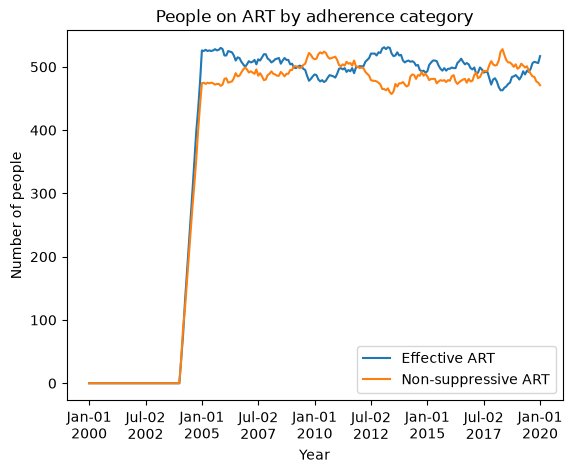

In [37]:
# Plot 1: number of people on effective vs. non-suppressive ART over time
fig1, ax1 = plt.subplots()
ax1.plot(timevec, hiv_res.n_on_effective_art, label='Effective ART')
ax1.plot(timevec, hiv_res.n_on_nonsuppressive_art, label='Non-suppressive ART')
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of people')
ax1.set_title('People on ART by adherence category')
ax1.legend()

#### Plot number and rates of deaths by ART status

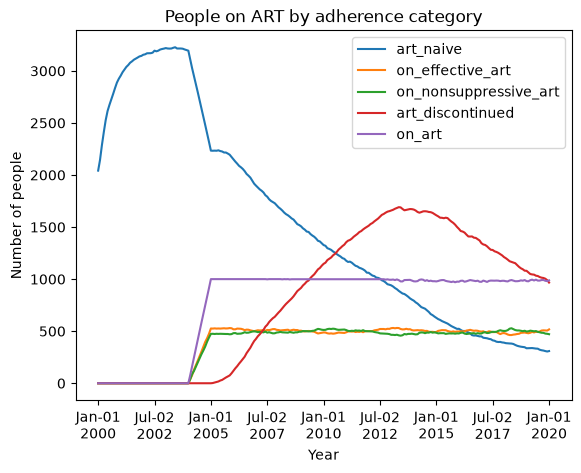

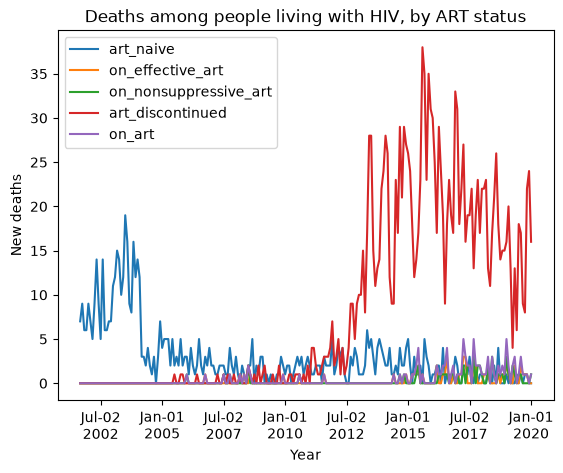

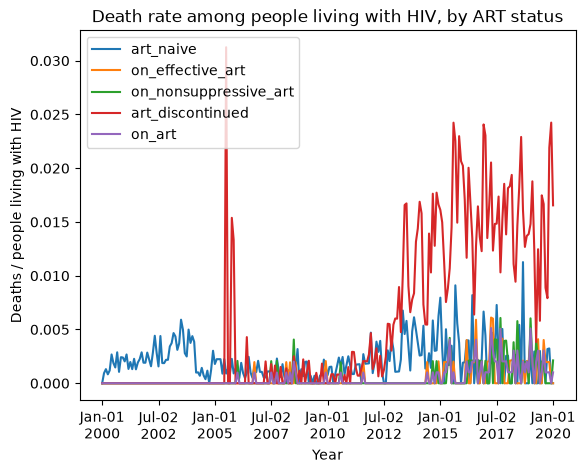

In [39]:
pops = get_by_art_status(sim, 'n_alive')
fig1, ax1 = plt.subplots()
for cat in groups:
    ax1.plot(timevec, pops[cat], label=cat)
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of people')
ax1.set_title('People on ART by adherence category')
ax1.legend()

# Plot 2: count of deaths among people living with HIV, by ART status
deaths = get_by_art_status(sim, 'deaths')
fig2, ax2 = plt.subplots()
for cat in groups:
    ax2.plot(timevec[20:], deaths[cat][20:], label=cat)
ax2.set_xlabel('Year')
ax2.set_ylabel('New deaths')
ax2.set_title('Deaths among people living with HIV, by ART status')
ax2.legend()

# Plot 3: death RATE (deaths / people living with HIV), by ART status
n_alive = get_by_art_status(sim, 'n_alive')
fig3, ax3 = plt.subplots()
for cat in groups:
    rate = np.divide(deaths[cat], n_alive[cat],
                      out=np.zeros_like(deaths[cat], dtype=float), where=(n_alive[cat] > 0))
    ax3.plot(timevec, rate, label=cat)
ax3.set_xlabel('Year')
ax3.set_ylabel('Deaths / people living with HIV')
ax3.set_title('Death rate among people living with HIV, by ART status')
ax3.legend()

#### Count numbers of onward transmissions

/var/folders/bd/msk_4j2n33xd2gh_w3_ts2sr0000gr/T/ipykernel_89638/3213775394.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax4.legend()


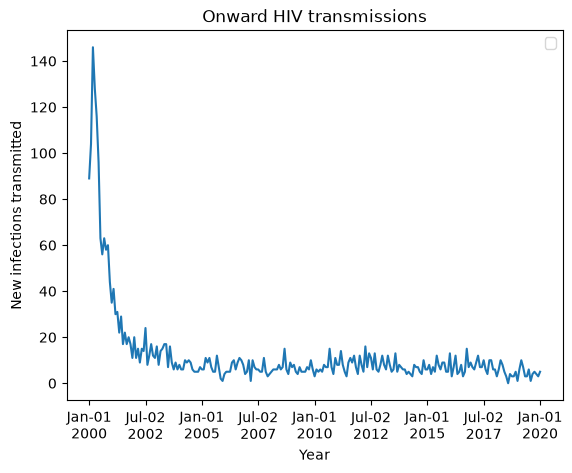

In [5]:
fig4, ax4 = plt.subplots()

ax4.plot(timevec, sim.results.hiv.new_infections)
ax4.set_xlabel('Year')
ax4.set_ylabel('New infections transmitted')
ax4.set_title('Onward HIV transmissions')
ax4.legend()

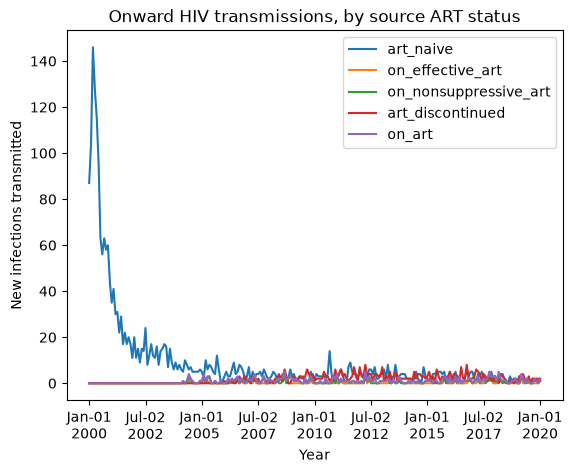

In [9]:
# Plot 4: onward transmissions, stratified by the SOURCE's ART status
new_infections = get_by_art_status(sim, 'new_infections_from')
fig4, ax4 = plt.subplots()
for cat in groups:
    ax4.plot(timevec, new_infections[cat], label=cat)
ax4.set_xlabel('Year')
ax4.set_ylabel('New infections transmitted')
ax4.set_title('Onward HIV transmissions, by source ART status')
ax4.legend()

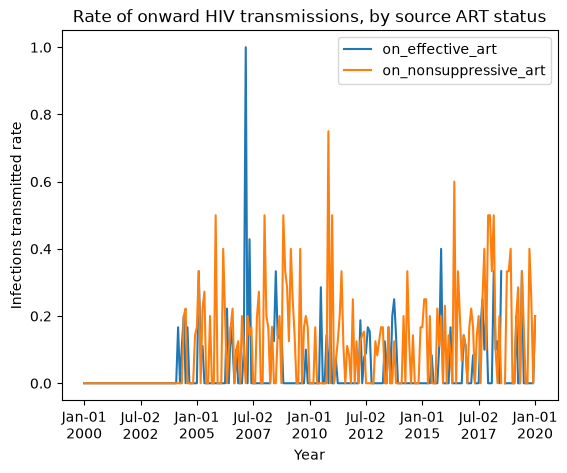

In [14]:
# Plot 5: onward transmissions, stratified by the SOURCE's ART status
new_infections = get_by_art_status(sim, 'new_infections_from')
n_alive = get_by_art_status(sim, 'n_alive')
fig5, ax5 = plt.subplots()
for cat in ['on_effective_art', 'on_nonsuppressive_art']:#groups:
    #ax5.plot(timevec, new_infections[cat]/n_alive[cat], label=cat)
    ax5.plot(timevec, new_infections[cat]/sim.results.hiv.new_infections, label=cat)
ax5.set_xlabel('Year')
ax5.set_ylabel('Infections transmitted rate')
ax5.set_title('Rate of onward HIV transmissions, by source ART status')
ax5.legend()

In [19]:
for cat in groups:
    print(cat, new_infections[cat].sum())

art_naive 2300.0
on_effective_art 71.0
on_nonsuppressive_art 158.0
art_discontinued 409.0
on_art 229.0
